In [45]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt


Adds all of the mileage across all of the sports and visualizes it across all of the data

<Axes: xlabel='year,week'>

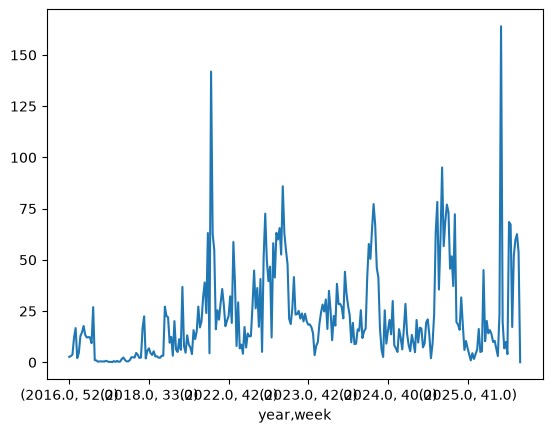

In [46]:
# weekly mileage across all activity types
activities = pd.read_csv("../data/processed/clean/clean_activities.csv")

weekly = (activities.groupby(["year", "week"])
          ["distance_miles"]
          .sum())

weekly.plot()

Averages the number of hours of sleep in a week and shows the trend across all of the data

<Axes: xlabel='year,week'>

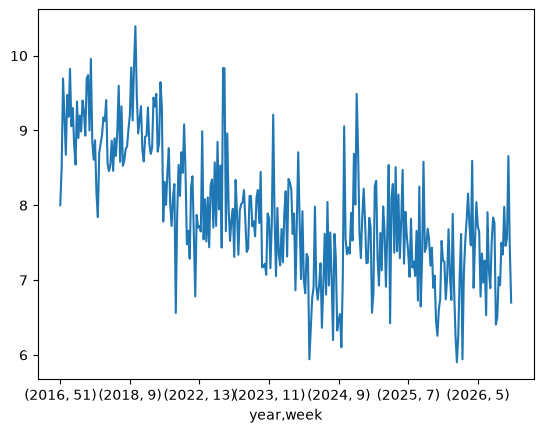

In [47]:
# Average hours of sleep per week -> clearly trending down :(

sleep = pd.read_csv("../data/processed/clean/clean_sleep.csv")

sleep_weekly = (sleep.groupby(["year", "week"])
                ["sleep_hours"]
                .mean())

sleep_weekly.plot()

This will eventually be a chart showing hours of sleep versus run pace. Currently having issues getting the points on the plot, but we'll get there

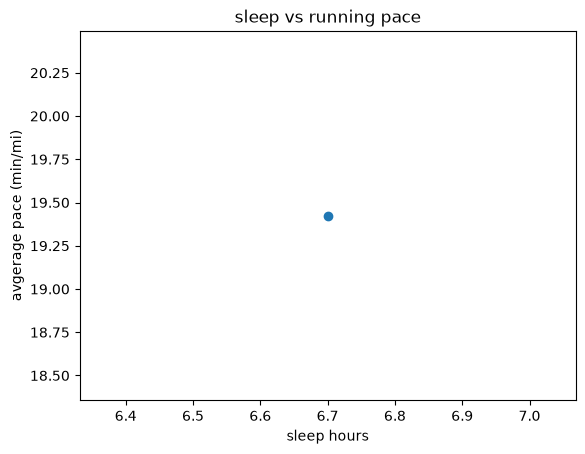

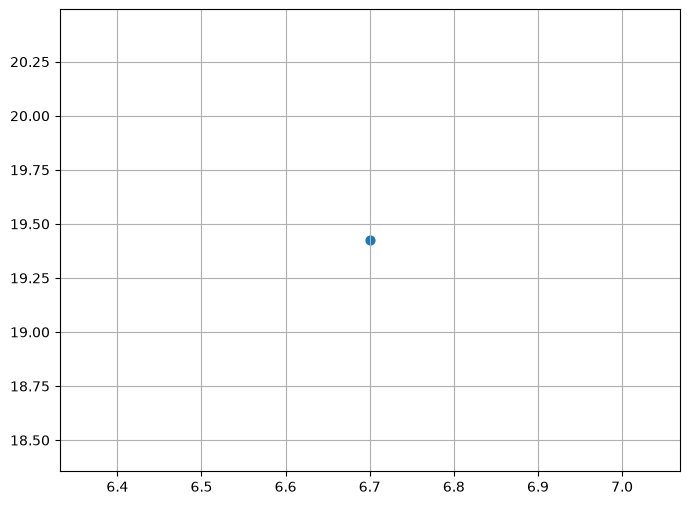

In [48]:
# Trying to get a plot showing hours of sleep versus run pace
# this one's a work in progress :)

runs = activities[activities["activity_type"].isin(["Running", "Treadmill Running"])].copy()

run_sleep = runs.merge(
    sleep,
    on="date",
    how="inner"
)

run_sleep.shape
run_sleep.head()
run_sleep["sleep_hours"] = pd.to_numeric(run_sleep["sleep_hours"], errors="coerce")
run_sleep["avg_pace"] = pd.to_numeric(run_sleep["avg_pace"], errors="coerce")
plot_df = run_sleep.dropna(subset=["sleep_hours", "avg_pace"])

plt.scatter(
    plot_df["sleep_hours"],
    plot_df["avg_pace"]
)

plt.xlabel("sleep hours")
plt.ylabel("avgerage pace (min/mi)")
plt.title("sleep vs running pace")
plt.figure(figsize=(8, 6))
plt.scatter(run_sleep["sleep_hours"], run_sleep["avg_pace"], s=40)
plt.grid(True)
plt.show()

get weekly mileage for designated week and sport (run, cycling, swimming, etc)